<a href="https://colab.research.google.com/github/kudp27-ops/Quantpath/blob/main/PO%2BSS%2BMC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade yfinance PyPortfolioOpt --quiet
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices
from pypfopt import plotting
START_DATE = "2022-01-01"
MIN_DOLLAR_VOLUME = 5_000_000
MIN_TRADING_DAYS = 400
MAX_STOCKS = 30
LOOKBACK_DAYS = 252
PORTFOLIO_VALUE = 100_000

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 6.5 MB/s eta 0:00:00


In [ ]:
sp500_url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv"
sp500_df = pd.read_csv(sp500_url)
UNIVERSE = sp500_df["Symbol"].str.replace(".", "-", regex=False).tolist()
data = yf.download(
    UNIVERSE,
    start=START_DATE,
    auto_adjust=True,
    progress=False
)
prices = data["Close"]
volume = data["Volume"]
prices = prices.dropna(axis=1, thresh=MIN_TRADING_DAYS)
volume = volume[prices.columns]
prices = prices.dropna()
volume = volume.loc[prices.index]
avg_dollar_volume = (prices * volume).mean()
liquid = avg_dollar_volume[avg_dollar_volume >= MIN_DOLLAR_VOLUME]
liquid = liquid.sort_values(ascending=False).head(MAX_STOCKS)
prices = prices[liquid.index]
returns = prices.pct_change().dropna()
momentum = prices.pct_change(LOOKBACK_DAYS).iloc[-1]
volatility = returns.std() * np.sqrt(252)
liquidity_score = avg_dollar_volume[prices.columns]
def zscore(s):
    return (s - s.mean()) / s.std()
score = (
    0.5 * zscore(momentum)
    - 0.3 * zscore(volatility)
    + 0.2 * zscore(liquidity_score)
)
ranked_stocks = score.sort_values(ascending=False)
ranked_stocks

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}
ERROR:yfinance:$WBA: possibly delisted; no timezone found
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: IPG"}}}
ERROR:yfinance:$IPG: possibly delisted; no timezone found
ERROR:yfinance:$FI: possibly delisted; no timezone found
ERROR:yfinance:$K: possibly delisted; no timezone found
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['WBA', 'IPG', 'FI', 'K']: possibly delisted; no timezone found


,0
Ticker,
MU,1.785223
NVDA,0.720532
GOOGL,0.409121
GOOG,0.354193
INTC,0.350028
AMD,0.320228
AAPL,0.242052
XOM,0.227955
WMT,0.168766


Optimal weights:
OrderedDict({'NVDA': 0.0, 'TSLA': 0.0, 'AAPL': 0.0, 'MSFT': 0.0, 'META': 0.0, 'AMZN': 0.0, 'AMD': 0.0, 'PLTR': 0.22472, 'GOOGL': 0.11207, 'AVGO': 0.0, 'GOOG': 0.0737, 'MU': 0.05569, 'NFLX': 0.0, 'UNH': 0.0, 'LLY': 0.0, 'SMCI': 0.0, 'ORCL': 0.0, 'COIN': 0.0, 'INTC': 0.0, 'JPM': 0.0, 'V': 0.0, 'BRK-B': 0.0, 'COST': 0.0, 'CRM': 0.0, 'XOM': 0.09435, 'WMT': 0.43946, 'BAC': 0.0, 'BA': 0.0, 'UBER': 0.0, 'ADBE': 0.0})
Expected annual return: 79.3%
Annual volatility: 23.1%
Sharpe Ratio: 3.43


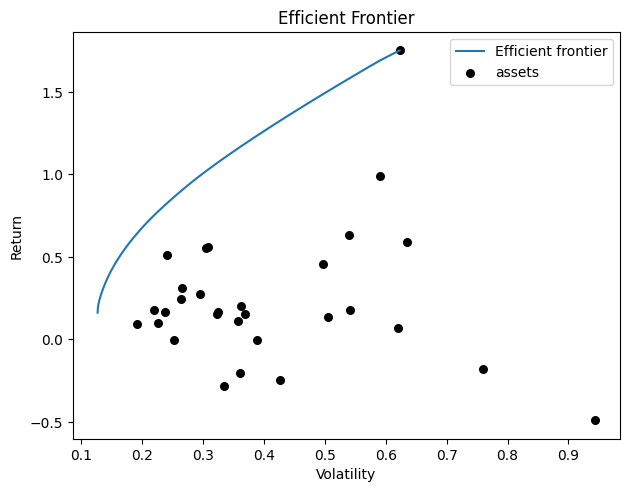


FINAL PORTFOLIO (From Portfolio Optimizer):
------------------------------------------
PLTR: 142 shares | $22,418.96
GOOGL: 33 shares | $11,210.43
GOOG: 22 shares | $7,495.40
MU: 13 shares | $5,452.72
XOM: 66 shares | $9,423.37
WMT: 344 shares | $43,932.24
------------------------------------------
Unallocated cash: $66.88


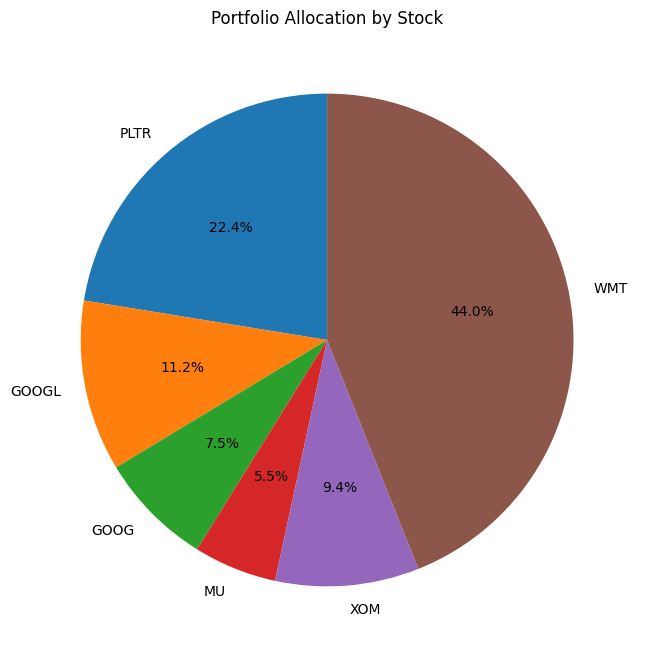

In [ ]:
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import plotting
import matplotlib.pyplot as plt
prices_opt = prices.copy()
mu = mean_historical_return(prices_opt)
S = CovarianceShrinkage(prices_opt).ledoit_wolf()
ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()
print("Optimal weights:")
print(cleaned_weights)
ef.portfolio_performance(verbose=True)
ef_plot = EfficientFrontier(mu, S)
plotting.plot_efficient_frontier(ef_plot)
plt.title("Efficient Frontier")
plt.show()
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices
latest_prices = get_latest_prices(prices_opt)
TOTAL_CAPITAL = 100_000
da = DiscreteAllocation(
    cleaned_weights,
    latest_prices,
    total_portfolio_value=TOTAL_CAPITAL
)
allocation, leftover = da.lp_portfolio()
print("\nFINAL PORTFOLIO (From Portfolio Optimizer):")
print("------------------------------------------")
for ticker, shares in allocation.items():
    price = latest_prices[ticker]
    dollar_amount = shares * price
    print(f"{ticker}: {shares} shares | ${dollar_amount:,.2f}")
print("------------------------------------------")
print(f"Unallocated cash: ${leftover:,.2f}")
labels = []
sizes = []
for ticker, shares in allocation.items():
    labels.append(ticker)
    sizes.append(shares * latest_prices[ticker])
plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Portfolio Allocation by Stock")
plt.show()

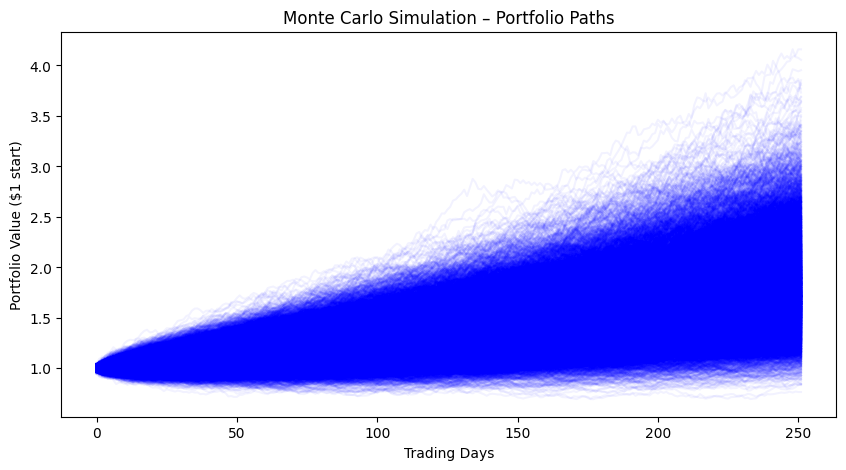

Probability of +20%: 96.08%
Probability of +30%: 91.97%
Probability of +40%: 86.61%
Median outcome: 1.81x
Worst 5% outcome: 1.23x


In [ ]:
weights_series = pd.Series(cleaned_weights)
weights_series = weights_series[weights_series > 0]
returns = prices[weights_series.index].pct_change().dropna()
weights_series = weights_series / weights_series.sum()
portfolio_returns = returns @ weights_series
mean_daily = portfolio_returns.mean()
std_daily = portfolio_returns.std()
NUM_SIMULATIONS = 10_000
TIME_HORIZON_DAYS = 252
simulated_daily_returns = np.random.normal(
    mean_daily,
    std_daily,
    (TIME_HORIZON_DAYS, NUM_SIMULATIONS)
)
paths = (1 + simulated_daily_returns).cumprod(axis=0)
plt.figure(figsize=(10,5))
plt.plot(paths, alpha=0.05, color="blue")
plt.title("Monte Carlo Simulation – Portfolio Paths")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value ($1 start)")
plt.show()
final_values = paths[-1]
print(f"Probability of +20%: {np.mean(final_values >= 1.20):.2%}")
print(f"Probability of +30%: {np.mean(final_values >= 1.30):.2%}")
print(f"Probability of +40%: {np.mean(final_values >= 1.40):.2%}")
print(f"Median outcome: {np.median(final_values):.2f}x")
print(f"Worst 5% outcome: {np.percentile(final_values, 5):.2f}x")